In [1]:
import sys
from pathlib import Path
import importlib.util
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import dataframe_image as dfi
import math
from itertools import combinations
import numpy as np

# notebooks/.. = project_root
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


package_dir = project_root / "scdb_code_map"
init_file = package_dir / "__init__.py"
init_file.touch(exist_ok=True)  # creates empty __init__.py if missing


spec = importlib.util.find_spec("scdb_code_map")
if spec is None:
    raise ImportError(f"Cannot find 'scdb_code_map' in {project_root}")


from scdb_code_map import VOTE_MAP, NATURAL_COURT_MAP

In [2]:
conn = sqlite3.connect("../data/legal_sc.db")
j_citations = pd.read_sql("SELECT * FROM j_citations", conn)
conn.close()
print(j_citations.columns.tolist())

['caseId', 'docketId', 'caseIssuesId', 'voteId', 'dateDecision', 'decisionType', 'usCite', 'sctCite', 'ledCite', 'lexisCite', 'term', 'naturalCourt', 'chief', 'docket', 'caseName', 'dateArgument', 'dateRearg', 'petitioner', 'petitionerState', 'respondent', 'respondentState', 'jurisdiction', 'adminAction', 'adminActionState', 'threeJudgeFdc', 'caseOrigin', 'caseOriginState', 'caseSource', 'caseSourceState', 'lcDisagreement', 'certReason', 'lcDisposition', 'lcDispositionDirection', 'declarationUncon', 'caseDisposition', 'caseDispositionUnusual', 'partyWinning', 'precedentAlteration', 'voteUnclear', 'issue', 'issueArea', 'decisionDirection', 'decisionDirectionDissent', 'authorityDecision1', 'authorityDecision2', 'lawType', 'lawSupp', 'lawMinor', 'majOpinWriter', 'majOpinAssigner', 'splitVote', 'majVotes', 'minVotes', 'justice', 'justiceName', 'vote', 'opinion', 'direction', 'majority', 'firstAgreement', 'secondAgreement']


In [3]:
# explore justice agreement networks: Which justices most often vote together?
# use caseID, justiceName, vote, majority and naturalCourt

# Keep only needed columns ---
df = j_citations[['caseId', 'justiceName', 'vote', 'majority', 'term', 'naturalCourt']].copy()

# Map votes to English words
df['vote_label'] = df['vote'].map(VOTE_MAP)

# Map majority to English labels
MAJORITY_MAP = {1: 'dissent', 2: 'majority'}
df['majority_label'] = df['majority'].map(MAJORITY_MAP)

# Drop rows with missing votes or majority
df = df.dropna(subset=['vote_label', 'majority_label'])

# Drop unanimous cases
df = df.groupby('caseId').filter(lambda x: x['vote_label'].nunique() > 1)

# Keep only cases with at least 2 justices
df = df.groupby('caseId').filter(lambda x: len(x) > 1)

# compute pairwise agreement matrix
def compute_agreement_matrix(df_subset, compare_column='vote_label'):
    """
    compare_column: either 'vote_label' or 'majority_label'
    """
    pairs_list = []
    for case_id, group in df_subset.groupby('caseId'):
        justices = group[['justiceName', compare_column]]
        for (j1, v1), (j2, v2) in combinations(justices.values, 2):
            pairs_list.append({
                'justice1': j1,
                'justice2': j2,
                'agree': int(v1 == v2)
            })
    
    pairs = pd.DataFrame(pairs_list)
    
    # Aggregate agreements
    agreement = (
        pairs
        .groupby(['justice1', 'justice2'])
        .agg(
            agreements=('agree', 'sum'),
            total_cases=('agree', 'count')
        )
        .reset_index()
    )
    
    agreement['agreement_rate'] = agreement['agreements'] / agreement['total_cases']
    
    # Pivot to matrix
    agreement_matrix = agreement.pivot(
        index='justice1',
        columns='justice2',
        values='agreement_rate'
    )
    
    # Make symmetric
    agreement_matrix = agreement_matrix.combine_first(agreement_matrix.T)
    
    # Fill diagonal with 1
    np.fill_diagonal(agreement_matrix.values, 1)
    
    return agreement_matrix

# Run analysis by natural court
natural_courts = df['naturalCourt'].unique()
agreement_matrices_vote = {}
agreement_matrices_majority = {}

for court in natural_courts:
    df_court = df[df['naturalCourt'] == court]
    
    # Vote agreement
    agreement_matrices_vote[court] = compute_agreement_matrix(df_court, compare_column='vote_label')
    
    # Majority agreement
    agreement_matrices_majority[court] = compute_agreement_matrix(df_court, compare_column='majority_label')
    
    print(f"\n=== Agreement Matrix by VOTE for Natural Court {court} ===")
    print(agreement_matrices_vote[court])
    
    print(f"\n=== Agreement Matrix by MAJORITY for Natural Court {court} ===")
    print(agreement_matrices_majority[court])


=== Agreement Matrix by VOTE for Natural Court 1301 ===
              FFrankfurter  FMVinson   FMurphy  HHBurton   HLBlack  RHJackson  \
justice1                                                                        
FFrankfurter      1.000000  0.512545  0.344948  0.500000  0.275000   0.384615   
FMVinson          0.357143  1.000000  0.692308  0.714286  0.571429   0.384615   
FMurphy           0.344948  0.500000  1.000000  0.769231  0.732394   0.333333   
HHBurton          0.533569  0.756272  0.390511  1.000000  0.460714   0.599251   
HLBlack           0.285714  0.550725  0.732394  0.642857  1.000000   0.307692   
RHJackson         0.681648  0.619772  0.347170  0.538462  0.328302   1.000000   
SFReed            0.357143  0.781022  0.466192  0.571429  0.547445   0.615385   
WBRutledge        0.268707  0.384058  0.727941  0.500000  0.670103   0.261649   
WODouglas         0.240876  0.466912  0.647482  0.500000  0.678967   0.384615   

                SFReed  WBRutledge  WODouglas  
jus

36
[1301, 1303, 1401, 1402, 1403, 1404, 1405, 1406, 1407, 1408, 1409, 1410, 1411, 1501, 1502, 1503, 1504, 1505, 1506, 1507, 1601, 1602, 1603, 1604, 1605, 1606, 1607, 1701, 1702, 1703, 1704, 1705, 1706, 1707, 1709, 1710]


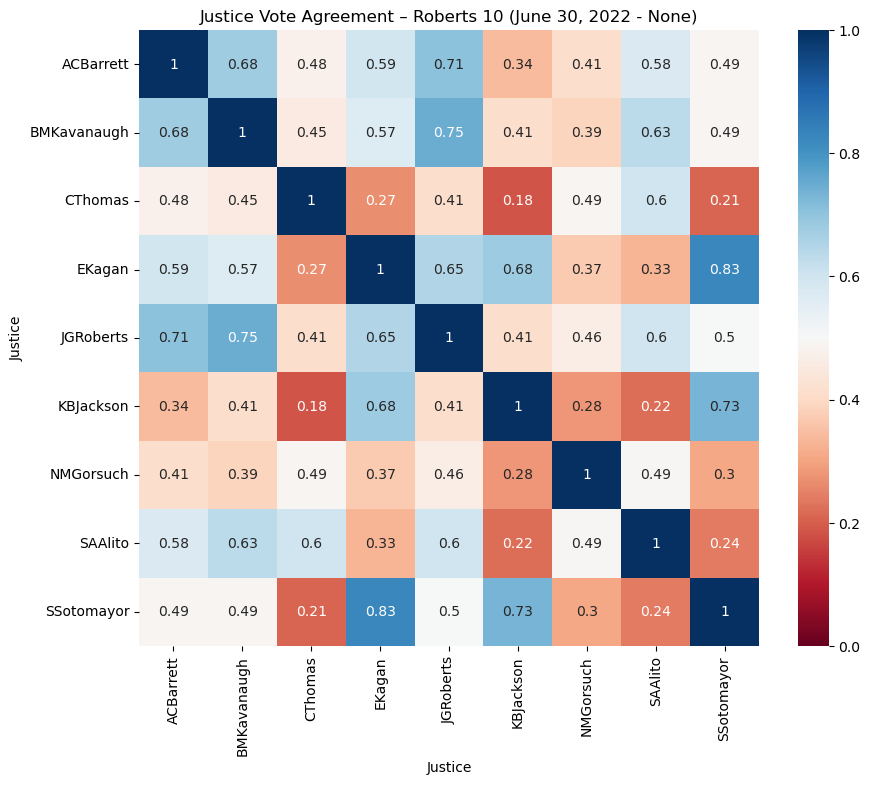

In [4]:
# visualize result using heat map
print(len(list(agreement_matrices_vote.keys())))
print(sorted(agreement_matrices_vote.keys()))
# print(list(map(type, NATURAL_COURT_MAP.keys())))
court = list(agreement_matrices_vote.keys())[35]
matrix = agreement_matrices_vote[court]

# Convert court code to readable label
court_info = NATURAL_COURT_MAP.get(court, {'name': str(court), 'start':'', 'end':''})
court_label = f"{court_info['name']} ({court_info['start']} - {court_info['end']})"

plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True, cmap="RdBu", vmin=0, vmax=1)

plt.title(f"Justice Vote Agreement – {court_label}")
plt.ylabel("Justice")
plt.xlabel("Justice")

plt.show()

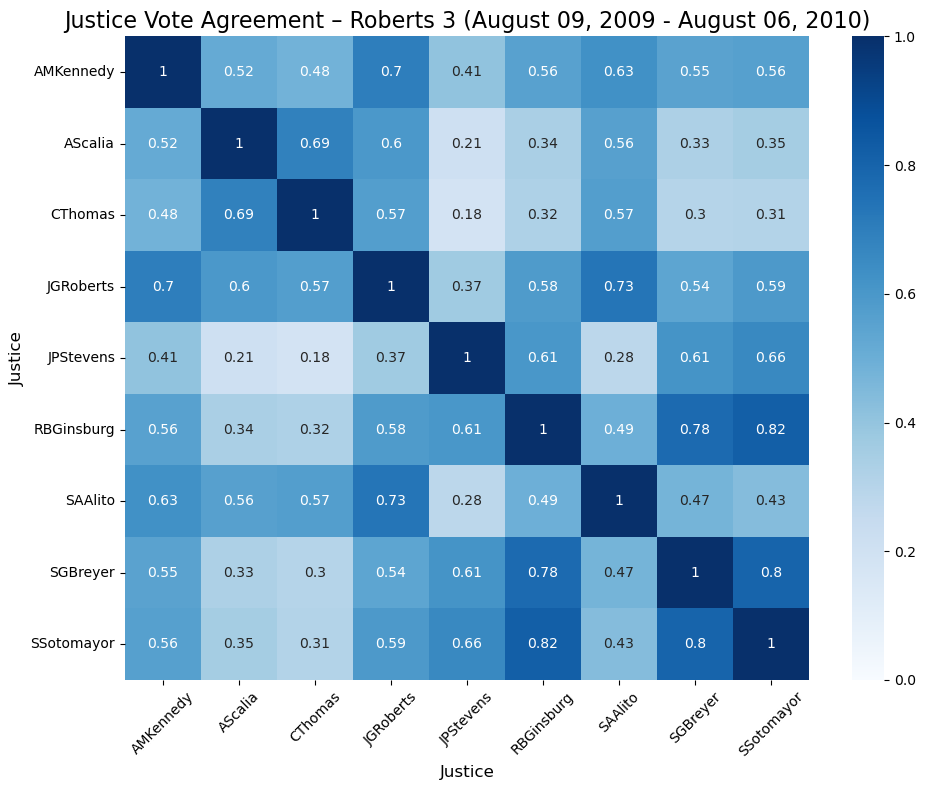

In [5]:
# Example: Roberts 3 (August 09, 2009 – August 06, 2010)

# Specify the natural court to showcase
showcase_court = 1703


# Get the agreement matrix for this court
matrix = agreement_matrices_vote[showcase_court]


# Get a readable label from NATURAL_COURT_MAP safely
# Provide defaults to avoid KeyError
court_info = NATURAL_COURT_MAP.get(showcase_court, {})
name = court_info.get('name', str(showcase_court))
start = court_info.get('start', '')
end = court_info.get('end', '')
court_label = f"{name} ({start} - {end})"


# sort justices alphabetically
matrix = matrix.sort_index().sort_index(axis=1)


# Plot the heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    matrix,
    annot=True,   # show agreement values
    cmap="Blues", # choose color theme
    vmin=0,
    vmax=1
)

plt.title(f"Justice Vote Agreement – {court_label}", fontsize=16)
plt.ylabel("Justice", fontsize=12)
plt.xlabel("Justice", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/justice_agreement.jpg', format='jpg', dpi=300)
plt.show()